In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
print('TF version:', tf.__version__)

TF version: 2.20.0


In [3]:
# Hyperparameters
MAX_VOCAB  = 20000
MAX_LEN    = 200
EMBED_DIM  = 128
BATCH_SIZE = 128
EPOCHS     = 10

In [4]:
# Load dataset and clean raw review text
def clean(text):
    text = re.sub(r'<[^>]+>', ' ', text)       # remove HTML tags
    text = text.lower()                         # lowercase
    text = re.sub(r'[^a-z\s]', '', text)       # remove punctuation and digits
    text = re.sub(r'\s+', ' ', text).strip()   # normalize whitespace
    return text

cwd = os.getcwd()
data_path = os.path.abspath(os.path.join(cwd, '..', '..', 'model', 'IMDB_Dataset.csv'))
df = pd.read_csv(data_path)
df['review'] = df['review'].apply(clean)
y = df['sentiment'].map({'positive': 1, 'negative': 0}).values
texts = df['review'].values
print(f'Loaded {len(df)} reviews')
df.head()

Loaded 50000 reviews


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [5]:
# Split data into train/val/test (70/10/20), tokenize vocabulary, and pad sequences to fixed length
X_train_t, X_test_t, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=y
)
X_train_t, X_val_t, y_train, y_val = train_test_split(
    X_train_t, y_train, test_size=0.125, random_state=42, stratify=y_train
)  # 0.125 x 0.8 = 0.1 of total

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_t)

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_t), maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val_t),   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(tokenizer.texts_to_sequences(X_test_t),  maxlen=MAX_LEN, padding='post', truncating='post')
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (35000, 200), Val: (5000, 200), Test: (10000, 200)


In [7]:
# Define 1D CNN model architecture
model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    BatchNormalization(),
    Conv1D(64, 3, activation='relu'),
    BatchNormalization(),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.build(input_shape=(None, MAX_LEN))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 196, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 196, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 194, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 194, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,671,681 (10.19 MB)

 Trainable params: 2,671,297 (10.19 MB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
# Train with early stopping and learning rate reduction on plateau
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 53s 181ms/step - accuracy: 0.5894 - loss: 0.7669 - val_accuracy: 0.6884 - val_loss: 0.6196 - learning_rate: 0.0010
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 50s 181ms/step - accuracy: 0.7972 - loss: 0.4478 - val_accuracy: 0.8466 - val_loss: 0.4429 - learning_rate: 0.0010
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 50s 183ms/step - accuracy: 0.8683 - loss: 0.3211 - val_accuracy: 0.8526 - val_loss: 0.3546 - learning_rate: 0.0010
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 50s 181ms/step - accuracy: 0.9106 - loss: 0.2311 - val_accuracy: 0.8572 - val_loss: 0.3454 - learning_rate: 0.0010
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 50s 182ms/step - accuracy: 0.9411 - loss: 0.1559 - val_accuracy: 0.8506 - val_loss: 0.3659 - learning_rate: 0.0010
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9670 - loss: 0.0920
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 51s 185ms/step - accuracy: 0.964

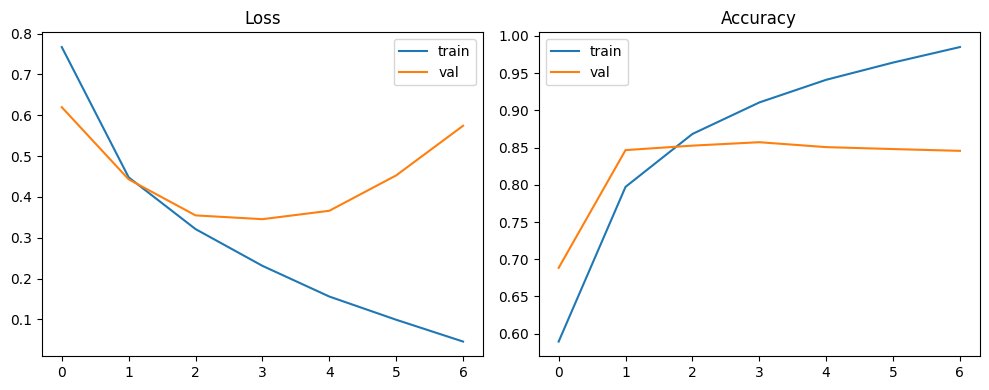

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step
Accuracy: 0.8489
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      5000
           1       0.85      0.85      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Evaluation images saved to c:\Users\HP\Desktop\AAAAAAAAAAAAAAAA\IMDB-Sentiment-Analysis-AMINE\results\model3_cnn


In [9]:
# Evaluate model and save training curves, confusion matrix, classification report
cwd = os.getcwd()
root_dir = os.path.abspath(os.path.join(cwd, '..', '..'))
results_dir = os.path.join(root_dir, 'results', 'model3_cnn')
os.makedirs(results_dir, exist_ok=True)

# Training curves
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'training_curves.png'), dpi=150)
plt.show()

# Predictions
y_pred = (model.predict(X_test, batch_size=256) >= 0.5).astype(int).flatten()
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - 1D CNN')
plt.xlabel('Predicted'); plt.ylabel('Actual')
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center', color='black')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'), dpi=150)
plt.close()

# Classification report
report = classification_report(y_test, y_pred, output_dict=True)
labels_order = ['0', '1', 'macro avg', 'weighted avg']
metrics = ['precision', 'recall', 'f1-score']
report_matrix = np.array([[report[l][m] for m in metrics] for l in labels_order if l in report], dtype=np.float32)
row_labels = [l for l in labels_order if l in report]
plt.figure(figsize=(6, 3.5))
plt.imshow(report_matrix, cmap='Greens', aspect='auto')
plt.title('Classification Report - 1D CNN')
plt.xticks(range(len(metrics)), metrics)
plt.yticks(range(len(row_labels)), row_labels)
for (i, j), v in np.ndenumerate(report_matrix):
    plt.text(j, i, f'{v:.2f}', ha='center', va='center', color='black')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'classification_report.png'), dpi=150)
plt.close()
print(f'Evaluation images saved to {results_dir}')

In [10]:
# Save model weights and tokenizer to results folder
model.save(os.path.join(results_dir, 'cnn_model.keras'))
with open(os.path.join(results_dir, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump({'tokenizer': tokenizer, 'max_len': MAX_LEN, 'max_vocab': MAX_VOCAB}, f)
print(f'Model saved to {results_dir}')

Model saved to c:\Users\HP\Desktop\AAAAAAAAAAAAAAAA\IMDB-Sentiment-Analysis-AMINE\results\model3_cnn
